# IEEE-CIS Fraud Detection: 비용 민감형 사기탐지 모델 개발
## Day 2. 통계검정 + 클래스 불균형 분석

**목표**
- 범주형 변수 vs isFraud: 카이제곱 검정
- 연속형 변수 vs isFraud: Mann-Whitney U test (Day 1에서 정규성 미충족 추정 확인)
- 그룹 결측 플래그 vs isFraud: 카이제곱 검정
- 클래스 불균형 정량화 및 처리 기법 결정

**Day 1에서 확정한 검정 대상**

| 구분 | 대상 변수 |
|---|---|
| 카이제곱 검정 | ProductCD, card4, card6, DeviceType, has_identity |
| Mann-Whitney U test | TransactionAmt, C1~C14, D1 |
| 결측 플래그 검정 대상 | addr_missing, M123_missing, M789_missing, V그룹15개 결측플래그, id_그룹 결측플래그 |

### 1. 라이브러리 임포트 및 Day 1 산출물 불러오기

Day 1에서 저장한 parquet 파일을 불러와 이어서 진행합니다. dtype과 파생변수(has_identity, TransactionAmt_log 등)가 그대로 복원되는지 확인합니다.

In [2]:
import pandas as pd
import numpy as np
from scipy import stats

pd.set_option('display.max_columns', 100)

df = pd.read_parquet("../data/processed/day1_merged.parquet")

print("shape:", df.shape)
print("\ndtype 복원 확인:")
print(f"addr1: {df['addr1'].dtype}, card1: {df['card1'].dtype}, isFraud: {df['isFraud'].dtype}")
print(f"\nTransactionAmt_log 존재 확인: {'TransactionAmt_log' in df.columns}")
print(f"has_identity 존재 확인: {'has_identity' in df.columns}")

shape: (590540, 437)

dtype 복원 확인:
addr1: category, card1: category, isFraud: int8

TransactionAmt_log 존재 확인: True
has_identity 존재 확인: True


### 2. 카이제곱 검정 (범주형 변수 vs isFraud)

Day 1에서 확정한 대상(ProductCD, card4, card6, DeviceType, has_identity)에 대해 카이제곱 독립성 검정을 수행합니다.

**가설**
- H0(귀무가설): 해당 변수와 isFraud는 서로 독립이다 (연관성 없음)
- H1(대안가설): 해당 변수와 isFraud는 서로 독립이 아니다 (연관성 있음)

**유의수준**: α = 0.05

In [3]:
def chi_square_test(df, col, target='isFraud'):
    """범주형 변수와 타겟 간 카이제곱 독립성 검정"""
    contingency = pd.crosstab(df[col], df[target])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    
    # 효과크기: Cramér's V (0~1, 클수록 연관성이 강함)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan
    
    return {
        'variable': col,
        'chi2': chi2,
        'p_value': p_value,
        'dof': dof,
        'cramers_v': cramers_v,
        'significant': p_value < 0.05
    }

chi_test_targets = ['ProductCD', 'card4', 'card6', 'DeviceType', 'has_identity']
chi_results = [chi_square_test(df, col) for col in chi_test_targets]

chi_results_df = pd.DataFrame(chi_results).sort_values('cramers_v', ascending=False)
print(chi_results_df.to_string(index=False))

    variable         chi2       p_value  dof  cramers_v  significant
   ProductCD 16742.171529  0.000000e+00    4   0.168376         True
has_identity 10683.635942  0.000000e+00    1   0.134504         True
       card6  5957.032292  0.000000e+00    3   0.100570         True
  DeviceType   609.623764 1.350769e-134    1   0.065798         True
       card4   364.874139  8.969834e-79    3   0.024890         True


**Cramér's V를 같이 넣은 이유:**
- 표본이 59만 건이나 되면, 사실상 거의 모든 변수가 p-value < 0.05로 "통계적으로 유의함"이 나옴. 표본이 클수록 작은 차이도 유의하게 잡히는 게 카이제곱 검정의 특성. 
- 그래서 p-value만 보면 "전부 유의함"이라는 별 의미 없는 결론에 그치기 쉬움. 
- Cramér's V(0~1 범위, 0이면 연관 없음, 1이면 완전한 연관)를 같이 확인해야함

### 카이제곱 검정 결과 요약

- 5개 변수 모두 p-value < 0.05로 통계적으로 유의함. 단, 표본 크기가 59만 건으로 매우 커서 p-value만으로는 실질적 연관 강도를 판단하기 어려우므로 Cramér's V를 함께 확인함
- ProductCD(V=0.168)와 has_identity(V=0.135)가 5개 변수 중 가장 강한 연관성을 보이며, 중간 수준의 연관 강도로 판단됨 → 핵심 변수로 확정
- card6(V=0.101)도 중간 수준에 근접한 연관성을 보임
- DeviceType(V=0.066)은 약한 수준의 연관성으로 확인됨
- card4(V=0.025)는 통계적으로는 유의하나 실질적 연관 강도가 매우 약해, 표본 크기에 의한 유의성으로 판단되며 변수 우선순위에서 낮게 분류함
- 종합적으로 ProductCD, has_identity가 4.3절 Feature Engineering 및 이후 모델링에서 우선적으로 고려할 변수로 확정됨

### 3. 그룹 결측 플래그 생성 및 카이제곱 검정

Day 1에서 확인한 동시 결측 그룹(addr1/addr2, M1~M3, M7~M9, V컬럼 15개 그룹)을 결측 플래그 변수로 생성하고, isFraud와의 연관성을 검정합니다.

### 참고: 결측 플래그(Missing Flag)의 의미와 생성 이유

**결측 플래그란**
- 원래 값이 결측(NaN)인지 아닌지를 0/1로 표현한 변수임
- 원래 값의 내용은 버리고 "비어있었다/비어있지 않았다"라는 사실 자체만 남긴 것임
- 예: `df['addr1'].isnull().astype(np.int8)` → addr1이 결측이면 1, 값이 있으면 0

**생성 이유**
- 결측 자체가 의미 있는 신호일 수 있기 때문임
- 본 프로젝트에서는 identity 보유 여부(has_identity) 자체가 사기 여부와 강하게 연관됨이 이미 확인됨(Day 1: 사기율 7.85% vs 2.09%, Day 2 카이제곱 검정: Cramér's V 0.135)
- 이는 "identity 컬럼의 실제 값"이 아니라 "identity 정보가 있다/없다"라는 사실 자체가 신호로 작동함을 의미함
- addr1/addr2가 100% 동시에 결측되는 패턴도 확인되어, "주소 정보를 남기지 않음" 자체가 특정 거래 패턴과 연결될 가능성이 있음

**모델링 관점에서의 필요성**
- 결측 플래그 없이 원변수를 그대로 사용하면, 모델이 결측값을 평균 대체·특수값 대체 등으로 처리하는 과정에서 "결측이었다"는 정보 자체가 희석될 수 있음
- 결측 여부를 별도 변수로 명시적으로 분리하면, 모델이 이 정보를 깔끔하게 학습할 수 있는 형태로 만들어줌

**본 프로젝트 맥락**
- IEEE-CIS는 원변수 다수가 익명화되어 값 자체의 의미 해석이 어려운 경우가 많음
- 반면 "이 변수가 결측인지 아닌지"는 익명화 여부와 무관하게 누구나 해석 가능한 정보이므로, 익명 변수에서도 해석 가능한 신호를 확보하는 방법으로 활용함

In [4]:
# 그룹별 결측 플래그 생성
df['addr_missing'] = df['addr1'].isnull().astype(np.int8)
df['M123_missing'] = df['M1'].isnull().astype(np.int8)
df['M789_missing'] = df['M7'].isnull().astype(np.int8)

flag_cols = ['addr_missing', 'M123_missing', 'M789_missing', 'has_identity']
flag_results = [chi_square_test(df, col) for col in flag_cols]

flag_results_df = pd.DataFrame(flag_results).sort_values('cramers_v', ascending=False)
print(flag_results_df.to_string(index=False))

    variable         chi2  p_value  dof  cramers_v  significant
addr_missing 15016.723471      0.0    1   0.159464         True
has_identity 10683.635942      0.0    1   0.134504         True
M123_missing  4720.578581      0.0    1   0.089407         True
M789_missing  2876.272466      0.0    1   0.069790         True


### 결측 플래그 카이제곱 검정 결과 요약

- addr_missing(V=0.159)이 결측 플래그 변수 중 가장 강한 연관성을 보였으며, 지금까지 검정한 전체 변수 중에서도 ProductCD(V=0.168)에 이어 두 번째로 높은 연관 강도로 확인됨
- has_identity(V=0.135)는 이전 검정 결과와 동일하게 중간 수준의 연관성을 유지함
- M123_missing(V=0.089)은 중간과 약함의 경계 수준으로 확인됨
- M789_missing(V=0.070)은 약한 수준이나 통계적으로는 유의함
- addr_missing이 단독으로 강한 신호를 보인다는 점에서, 주소 정보 누락 여부 자체가 사기 패턴과 밀접하게 연관된 것으로 판단되며 4.3절 Feature Engineering에서 핵심 변수로 채택함

### 4. V컬럼 15개 그룹 결측 플래그 생성 및 검정

Day 1에서 확인한 V컬럼 339개 → 15개 결측 그룹(100% 패턴 일치)을 기준으로, 그룹별 결측 플래그를 생성하고 isFraud와의 연관성을 검정합니다. 그룹 내 컬럼들이 동시에 결측되므로, 그룹의 첫 번째 컬럼만으로 결측 여부를 판단해도 전체 그룹을 대표할 수 있습니다.

In [5]:
v_cols = [c for c in df.columns if c.startswith('V')]
v_missing_pct = (df[v_cols].isnull().sum() / len(df) * 100).round(4)

v_group_df = v_missing_pct.reset_index()
v_group_df.columns = ['column', 'missing_pct']
v_groups = v_group_df.groupby('missing_pct')['column'].apply(list).reset_index()

v_flag_results = []
for i, row in v_groups.iterrows():
    representative_col = row['column'][0]  # 그룹 내 첫 컬럼으로 결측 여부 판단 (100% 동시 결측이므로 대표 가능)
    flag_name = f'V_group{i+1}_missing'
    df[flag_name] = df[representative_col].isnull().astype(np.int8)
    
    result = chi_square_test(df, flag_name)
    result['n_cols_in_group'] = row['n_cols'] if 'n_cols' in row else len(row['column'])
    v_flag_results.append(result)

v_flag_df = pd.DataFrame(v_flag_results).sort_values('cramers_v', ascending=False)
print(v_flag_df.to_string(index=False))

         variable         chi2       p_value  dof  cramers_v  significant  n_cols_in_group
V_group10_missing 10589.788388  0.000000e+00    1   0.133912         True               19
V_group11_missing 10515.979118  0.000000e+00    1   0.133444         True               31
 V_group9_missing 10023.654629  0.000000e+00    1   0.130283         True               16
V_group12_missing  9230.056519  0.000000e+00    1   0.125019         True               46
 V_group8_missing  4605.068214  0.000000e+00    1   0.088307         True               11
 V_group5_missing  1448.913241  0.000000e+00    1   0.049533         True               22
 V_group4_missing   670.267859 8.736834e-148    1   0.033690         True               23
 V_group6_missing   522.484771 1.218848e-115    1   0.029745         True               20
V_group13_missing   270.166940  1.043579e-60    1   0.021389         True               18
V_group14_missing   257.284254  6.706495e-58    1   0.020873         True               11

### V컬럼 15개 그룹 결측 플래그 검정 결과 요약

- 15개 그룹 중 12개 그룹이 통계적으로 유의함(p<0.05), 3개 그룹(V_group1, 2, 3)은 유의하지 않아 결측 여부가 사기와 무관한 것으로 확인됨
- V_group10, 11, 9, 12(Cramér's V 0.125~0.134)가 가장 강한 연관성을 보이며, has_identity(0.135)와 거의 동등한 수준의 핵심 신호로 확인됨 → 해당 4개 그룹(컬럼 112개)의 결측 플래그를 4.3절 핵심 파생변수로 확정함
- V_group8(0.088)은 중간 수준, V_group4·5·6(0.030~0.050)은 약한 수준의 연관성을 보임
- V_group13·14·15(0.021)와 V_group7(0.004)은 유의하지만 연관 강도가 매우 낮아 실질적 활용 가치가 제한적인 것으로 판단됨
- V_group1·2·3(전체 V컬럼의 약 25%인 86개 컬럼)은 결측 여부가 사기와 통계적으로 무관함이 확인됨. 단, 이는 결측 여부에 한정된 결과이며 해당 그룹 내 실제 값(컬럼 내용)의 유의성은 별도로 SHAP 분석(4.10절)에서 추가 확인이 필요함

### 5. 정규성 검정 (연속형 변수)

TransactionAmt, C1~C14, D1에 대해 정규성을 확인합니다. 표본이 59만 건으로 매우 크기 때문에, 검정 방법별 적용 가능 범위를 고려하여 다음 순서로 진행합니다.

1. **히스토그램 + Q-Q plot**: 분포 형태와 정규분포로부터의 이탈을 시각적으로 확인
2. **D'Agostino-Pearson test**: 왜도+첨도 기반, 5만 건 샘플링하여 적용 (주 검정)
3. **Anderson-Darling test**: 분포 꼬리 차이에 민감, 대표본에도 적용 가능 (보강)
4. **Shapiro-Wilk test**: 5,000건 이하 샘플링 시에만 신뢰할 수 있으므로, 별도 소규모 샘플로 참고용 확인 (공식적으로 5,000건 초과 표본에는 권장되지 않음)

In [7]:
continuous_vars = ['TransactionAmt'] + [f'C{i}' for i in range(1, 15)] + ['D1']

In [13]:
# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

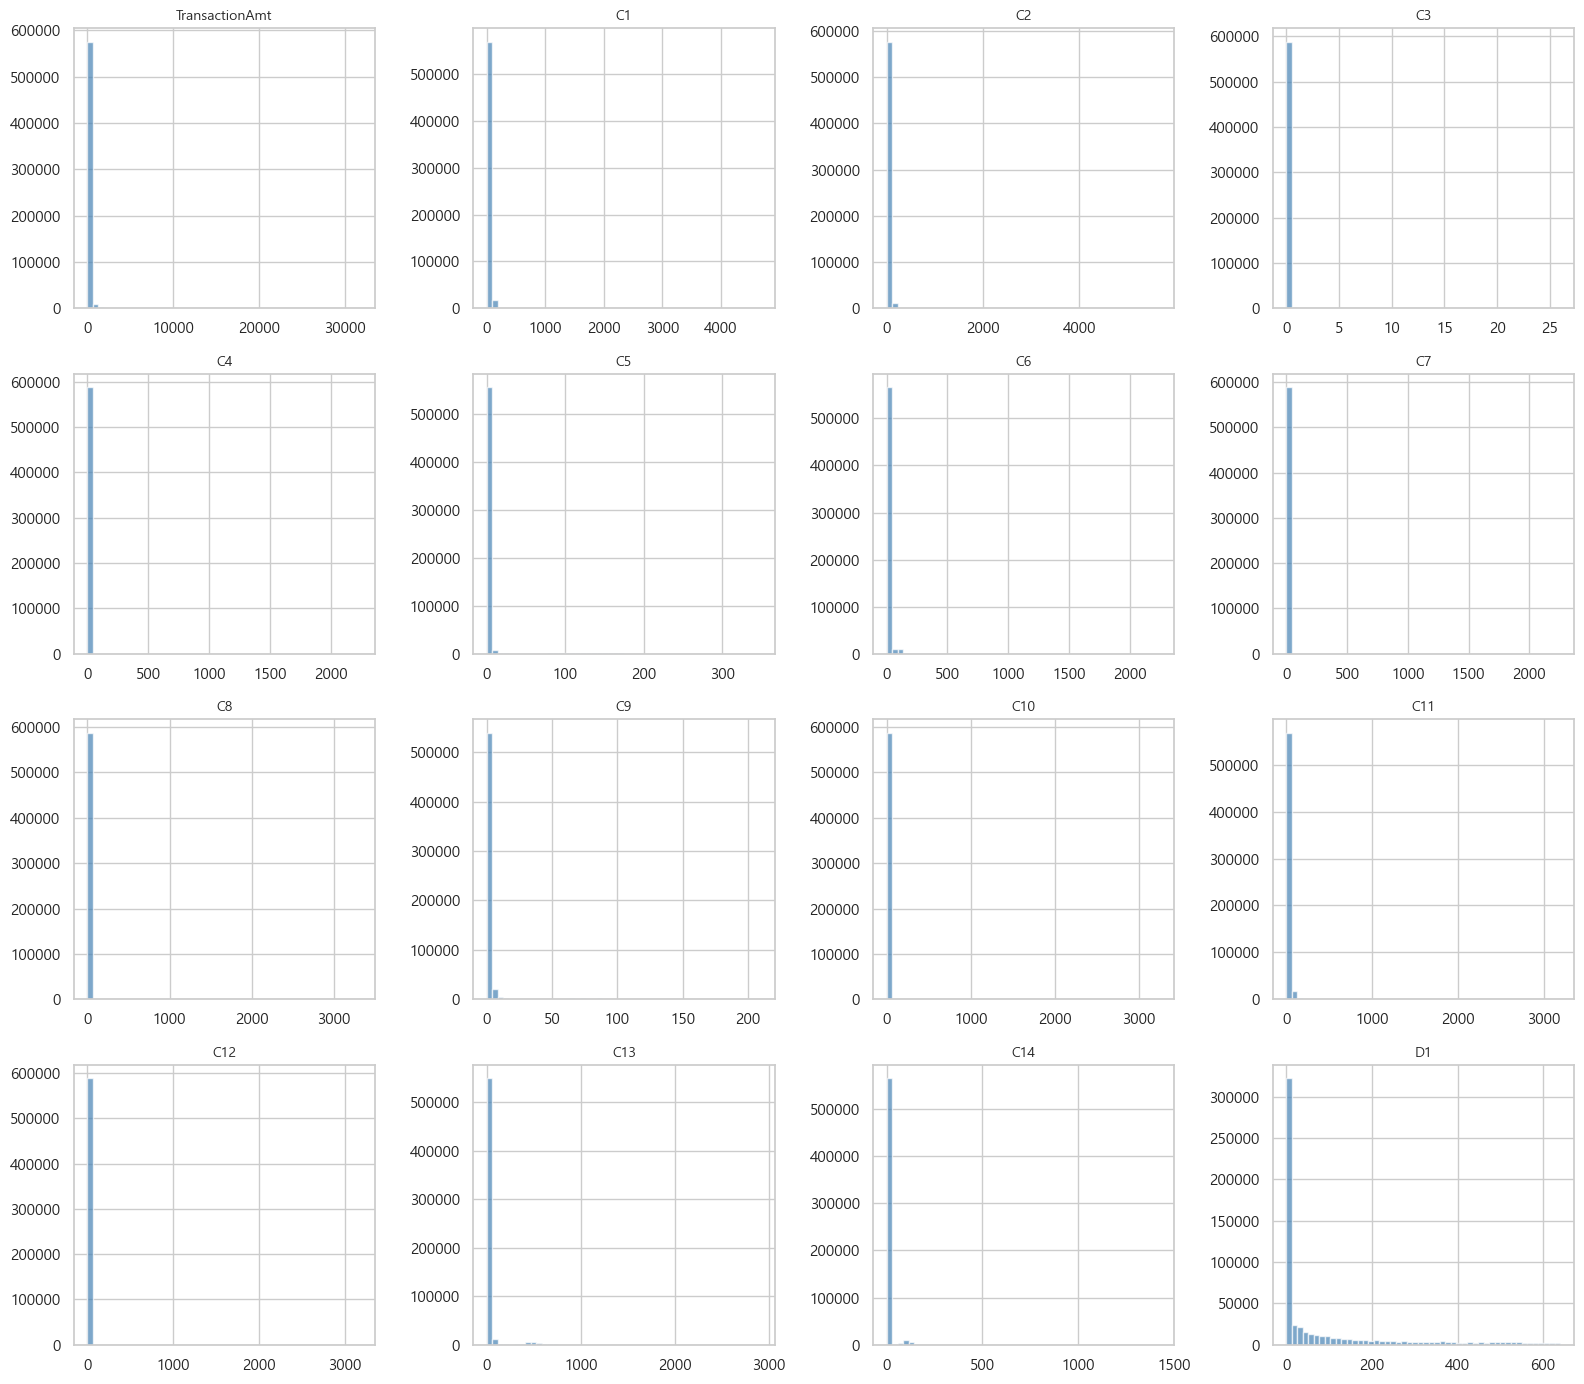

In [14]:
from matplotlib import pyplot as plt
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(continuous_vars):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', alpha=0.7)
    axes[i].set_title(col, fontsize=10)

for j in range(len(continuous_vars), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('../reports/figures/day2_histograms_continuous.png', dpi=100)
plt.show()

### 6. Q-Q Plot 확인 (TransactionAmt 대표)

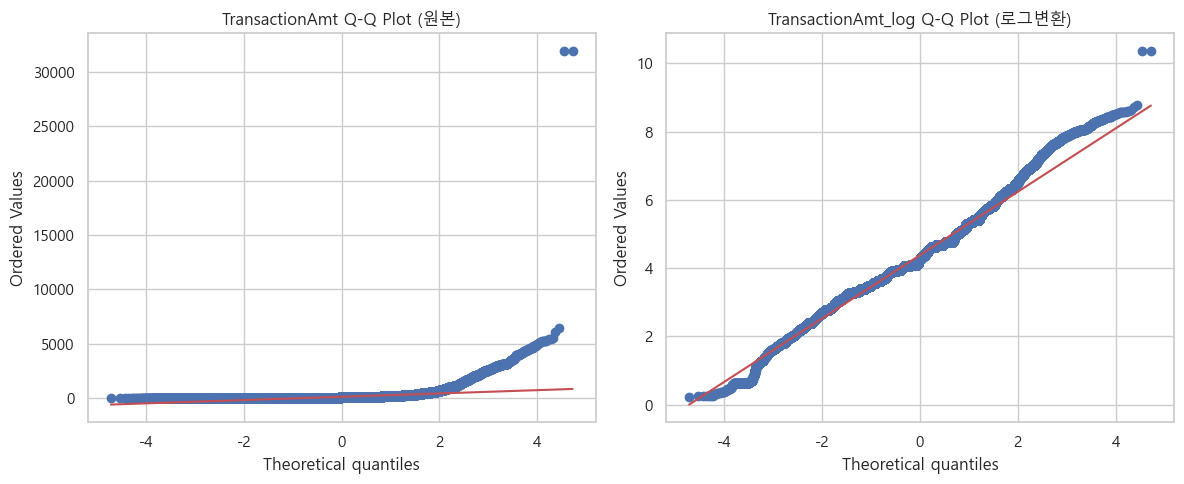

In [15]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scipy_stats.probplot(df['TransactionAmt'].dropna(), dist="norm", plot=axes[0])
axes[0].set_title('TransactionAmt Q-Q Plot (원본)')

scipy_stats.probplot(df['TransactionAmt_log'].dropna(), dist="norm", plot=axes[1])
axes[1].set_title('TransactionAmt_log Q-Q Plot (로그변환)')

plt.tight_layout()
plt.savefig('../reports/figures/day2_qqplot_transactionamt.png', dpi=100)
plt.show()

### 7. 정규성 검정 (D'Agostino-Pearson + Anderson-Darling + Shapiro-Wilk 참고)

In [16]:
from scipy.stats import normaltest, anderson, shapiro

normality_results = []
for col in continuous_vars:
    data = df[col].dropna()
    skewness = stats.skew(data)
    kurt = stats.kurtosis(data)
    
    # D'Agostino-Pearson (5만 샘플링)
    sample_50k = data.sample(min(len(data), 50000), random_state=42)
    dag_stat, dag_p = normaltest(sample_50k)
    
    # Anderson-Darling (전체 데이터 적용 가능)
    ad_result = anderson(data, dist='norm')
    ad_critical_5pct = ad_result.critical_values[2]  # 5% 유의수준 임계값
    ad_normal = ad_result.statistic < ad_critical_5pct
    
    # Shapiro-Wilk (5000건 이하로 별도 샘플링, 참고용)
    sample_5k = data.sample(min(len(data), 5000), random_state=42)
    sw_stat, sw_p = shapiro(sample_5k)
    
    normality_results.append({
        'variable': col,
        'skewness': round(skewness, 3),
        'kurtosis': round(kurt, 3),
        'dagostino_p': dag_p,
        'anderson_stat': round(ad_result.statistic, 2),
        'anderson_normal(5%)': ad_normal,
        'shapiro_p(ref)': sw_p,
    })

normality_df = pd.DataFrame(normality_results)
print(normality_df.to_string(index=False))

      variable  skewness     kurtosis  dagostino_p  anderson_stat  anderson_normal(5%)  shapiro_p(ref)
TransactionAmt 14.374000  1123.947998          0.0       92524.70                False    1.718082e-81
            C1 23.958000   669.375000          0.0      197487.69                False    2.556049e-94
            C2 23.677000   655.168030          0.0      200355.07                False    2.059486e-94
            C3 88.949997 11000.347656          0.0      225404.42                False    3.724343e-95
            C4 22.077999   543.408020          0.0      221992.55                False    8.849688e-95
            C5  5.794000    35.985001          0.0      192646.32                False    2.403087e-90
            C6 19.767000   463.825012          0.0      193035.78                False    7.067620e-94
            C7 27.194000   793.997009          0.0      223834.41                False    4.113453e-95
            C8 26.083000   742.405029          0.0      221415.02        

### 정규성 검정 결과 요약

- 히스토그램에서 모든 변수가 0 근처에 극도로 밀집되고 소수의 극단값이 매우 멀리 떨어져 있는 형태로 확인됨 → 정규분포(종모양)와 명확히 다른 형태임
- Q-Q Plot에서 점들이 이론적 정규분포 대각선에서 크게 벗어나며, 특히 우측 꼬리에서 급격한 이탈이 나타남. 로그변환(TransactionAmt_log) 후에도 중간 구간은 개선되나 양쪽 꼬리의 이탈은 해소되지 않음
- 왜도가 전 변수에서 1.8~89로 매우 크게 나타나(정규분포 기준값 0), 극심한 우측 비대칭 분포로 확인됨
- 첨도 역시 전 변수에서 매우 크게 나타나(C3의 경우 11,000 이상), 극단값이 정규분포 대비 비정상적으로 많은 것으로 확인됨
- D'Agostino-Pearson, Anderson-Darling, Shapiro-Wilk(참고) 세 검정 방법 모두에서 전 변수가 정규성 기각으로 일치된 결론을 보임
- **결론**: TransactionAmt, C1~C14, D1 전체가 정규성을 따르지 않는 것으로 확인되어, 이후 사기/정상 그룹 간 분포 차이 검정은 t-test가 아닌 **Mann-Whitney U test**(비모수 검정)를 사용하는 것이 타당함

### 8. Mann-Whitney U test (연속형 변수 vs isFraud)

정규성이 기각되었으므로, 사기/정상 그룹 간 분포 차이를 비모수 검정인 Mann-Whitney U test로 확인합니다. 효과크기는 rank-biserial correlation으로 함께 산출합니다.

In [17]:
from scipy.stats import mannwhitneyu

def mannwhitney_test(df, col, target='isFraud'):
    group0 = df.loc[df[target] == 0, col].dropna()
    group1 = df.loc[df[target] == 1, col].dropna()
    
    u_stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
    
    # 효과크기: rank-biserial correlation (r = 1 - (2U) / (n0*n1))
    n0, n1 = len(group0), len(group1)
    r_effect = 1 - (2 * u_stat) / (n0 * n1)
    
    return {
        'variable': col,
        'median_normal': group0.median(),
        'median_fraud': group1.median(),
        'u_stat': u_stat,
        'p_value': p_value,
        'effect_size_r': abs(r_effect),
        'significant': p_value < 0.05
    }

mw_results = [mannwhitney_test(df, col) for col in continuous_vars]
mw_df = pd.DataFrame(mw_results).sort_values('effect_size_r', ascending=False)
print(mw_df.to_string(index=False))

      variable  median_normal  median_fraud       u_stat      p_value  effect_size_r  significant
            C4            0.0           1.0 3677500718.0 0.000000e+00       0.375391         True
            C8            0.0           1.0 3730634499.5 0.000000e+00       0.366366         True
           C10            0.0           1.0 3792587661.0 0.000000e+00       0.355844         True
           C12            0.0           0.0 3962877404.0 0.000000e+00       0.326921         True
            C7            0.0           0.0 4151538973.5 0.000000e+00       0.294877         True
            C5            0.0           0.0 7564704146.5 0.000000e+00       0.284835         True
            C9            1.0           0.0 7536567522.0 0.000000e+00       0.280056         True
            C2            1.0           2.0 4370062923.0 0.000000e+00       0.257762         True
           C13            3.0           1.0 7247811137.0 0.000000e+00       0.231012         True
            C1      

### Mann-Whitney U test 결과 요약

- TransactionAmt는 통계적으로 유의하지 않음(p=0.226, effect size=0.005)으로 확인됨. Day 1에서 관찰한 "사기 그룹의 분포가 더 넓게 퍼짐(분산 차이)" 패턴은 중심경향 차이를 검정하는 Mann-Whitney로는 포착되지 않는 것으로 판단되며, 원본 금액보다는 분산 기반 파생변수(금액 편차 z-score)에서 신호를 찾는 것이 타당함
- C4, C8, C10, C12가 효과크기 0.3 이상으로 매우 강한 신호를 보임 → 4.3절 핵심 입력 변수로 확정
- C7, C5, C9, C2, C13, C1, C11(효과크기 0.2~0.3)도 중간~강한 수준의 신호로 확인됨
- D1은 효과크기 0.190으로 중간 수준이며, 정상 거래 중앙값(4일) 대비 사기 거래 중앙값(0일)으로 나타나 신규 계정/카드일수록 사기 위험이 높다는 패턴이 확인됨 → UID 설계 변수로서의 타당성을 추가로 지지함
- C3는 통계적으로 유의하나 효과크기가 0.004로 극히 작아 실질적 의미가 없는 것으로 판단되며, 표본 크기에 의한 유의성으로 해석됨
- 종합적으로 C4·C8·C10·C12·D1이 연속형 변수 중 가장 강력한 사기탐지 신호로 확정되며, TransactionAmt는 원본 형태가 아닌 파생변수 형태로 재설계가 필요한 것으로 판단됨

### 9. TransactionAmt 분산 신호 사전 검증 (UID 기반 금액 편차)

Mann-Whitney U test에서 TransactionAmt 원본값은 유의하지 않았으나, Day 1 시각화에서 관찰된 분산 차이가 실제 신호인지 확인합니다. card1, card2, addr1, D1을 조합한 간이 UID를 만들고, 사용자(UID) 평소 거래금액 대비 이번 거래의 z-score를 계산하여 검증합니다.

이 UID는 4.3절 본 설계 전의 사전 검증용 간이 버전이며, 정식 UID 설계와 매칭 정확도 검토는 Day 3에서 진행합니다.

In [18]:
# 간이 UID 생성 (검증용)
df['UID_temp'] = (
    df['card1'].astype(str) + '_' +
    df['card2'].astype(str) + '_' +
    df['addr1'].astype(str) + '_' +
    df['D1'].astype(str)
)

print(f"고유 UID 개수: {df['UID_temp'].nunique():,} / 전체 거래 {len(df):,}건")
print(f"UID당 평균 거래 건수: {len(df) / df['UID_temp'].nunique():.2f}")

# UID 그룹 내 거래 건수 분포 확인 (1건짜리 UID가 너무 많으면 z-score 계산이 불안정)
uid_counts = df['UID_temp'].value_counts()
print(f"\nUID별 거래 건수 분포:\n{uid_counts.describe()}")
print(f"\n거래 1건뿐인 UID 비율: {(uid_counts == 1).sum() / len(uid_counts):.1%}")

고유 UID 개수: 248,038 / 전체 거래 590,540건
UID당 평균 거래 건수: 2.38

UID별 거래 건수 분포:
count    248038.000000
mean          2.380845
std          22.877262
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        7174.000000
Name: count, dtype: float64

거래 1건뿐인 UID 비율: 73.4%


### 9-1. UID 조합 재검토

D1(경과일)은 거래마다 값이 달라지는 변수이므로 UID 조합에 포함하면 동일 사용자도 매 거래마다 다른 UID로 분리되는 문제가 발생합니다. D1을 제외한 조합으로 재검증합니다.

In [19]:
df['UID_v2'] = (
    df['card1'].astype(str) + '_' +
    df['card2'].astype(str) + '_' +
    df['addr1'].astype(str)
)

print(f"고유 UID 개수: {df['UID_v2'].nunique():,} / 전체 거래 {len(df):,}건")
print(f"UID당 평균 거래 건수: {len(df) / df['UID_v2'].nunique():.2f}")

uid_v2_counts = df['UID_v2'].value_counts()
print(f"\nUID별 거래 건수 분포:\n{uid_v2_counts.describe()}")
print(f"\n거래 1건뿐인 UID 비율: {(uid_v2_counts == 1).sum() / len(uid_v2_counts):.1%}")

고유 UID 개수: 41,672 / 전체 거래 590,540건
UID당 평균 거래 건수: 14.17

UID별 거래 건수 분포:
count    41672.000000
mean        14.171146
std        103.207016
min          1.000000
25%          1.000000
50%          2.000000
75%          7.000000
max       9900.000000
Name: count, dtype: float64

거래 1건뿐인 UID 비율: 40.3%


### 참고: D1 변수 해석에 대한 정정

앞서 D1을 "첫 거래 이후 경과일"로 단정적으로 설명했으나, 이는 부정확한 표현으로 정정함.

**Kaggle 공식 설명(명시된 사실)**
- D1~D15는 "timedelta, such as days between previous transaction, etc."로만 설명되어 있음
- 즉 D1~D15가 날짜 차이(timedelta) 계열 변수라는 점만 공식적으로 명시되어 있음
- 각 D컬럼이 정확히 무엇과의 날짜 차이인지(이전 거래, 카드 발급일, 계정 생성일 등)는 공식적으로 컬럼별로 명시되어 있지 않음

**일반적 추정(Kaggle 커뮤니티 분석 기반, 비공식)**
- D1은 흔히 "카드 최초 사용 시점부터의 경과일" 또는 "카드/계정의 사용 기간(나이)"로 추정되는 경우가 많음
- 이는 D1 값의 분포 패턴(신규 거래일수록 작은 값)에 기반한 추론이며 공식적으로 확인된 정의는 아님

**본 프로젝트에서의 처리 원칙**
- 통계검정 결과(카이제곱, Mann-Whitney에서 D1과 isFraud 간 유의한 연관성 확인)는 사실로서 유효함
- 다만 "D1 값이 낮을수록 사기 비율이 높다 = 신규 계정/카드일수록 위험하다"는 해석은 일반적 추정에 근거한 것이며, 단정적 사실로 서술하지 않음
- 보고서 및 블로그 작성 시, 익명 변수의 의미 해석 부분은 모두 "~로 추정됨", "~와 일치하는 패턴" 등 추정 표현을 사용하고, Kaggle 공식 설명과 커뮤니티 추정을 명확히 구분하여 기술함

### 9-2. UID 기준 금액 편차(z-score) 계산 및 검증

card1+card2+addr1 기준 UID로 그룹화하여, 그룹 내 평균/표준편차 대비 이번 거래금액의 z-score를 계산합니다. 그룹 내 거래가 1건뿐이거나 표준편차가 0인 경우(편차 계산 불가)는 결측으로 처리하고, 그 비율도 별도로 확인합니다.

In [21]:
uid_stats = df.groupby('UID_v2')['TransactionAmt'].agg(['mean', 'std', 'count'])
df = df.merge(uid_stats, on='UID_v2', how='left', suffixes=('', '_uid'))

# z-score 계산 (표준편차가 0이거나 NaN인 경우, 즉 거래가 1건뿐인 경우는 계산 불가 -> NaN)
df['amt_zscore'] = np.where(
    (df['std'] > 0) & df['std'].notna(),
    (df['TransactionAmt'] - df['mean']) / df['std'],
    np.nan
)

print(f"z-score 계산 불가 비율: {df['amt_zscore'].isnull().mean():.1%}")
print(f"\nz-score 기초통계:\n{df['amt_zscore'].describe()}")

# Mann-Whitney 재검정
result = mannwhitney_test(df, 'amt_zscore')
print(f"\n[amt_zscore Mann-Whitney 검정]")
print(result)

z-score 계산 불가 비율: 3.9%

z-score 기초통계:
count    5.676630e+05
mean    -4.472834e-08
std      9.800166e-01
min     -4.125851e+00
25%     -5.001433e-01
50%     -2.851255e-01
75%      1.781316e-01
max      2.623477e+01
Name: amt_zscore, dtype: float64

[amt_zscore Mann-Whitney 검정]
{'variable': 'amt_zscore', 'median_normal': np.float32(-0.2881833), 'median_fraud': np.float32(-0.16236205), 'u_stat': np.float64(4890511186.0), 'p_value': np.float64(4.513382329725356e-125), 'effect_size_r': np.float64(0.09929567309403131), 'significant': np.True_}


In [22]:
print(f"merge 전후 행 개수 비교: 원본 590,540 vs 현재 {len(df):,}")

merge 전후 행 개수 비교: 원본 590,540 vs 현재 590,540


### 참고: "그룹 기준 비율"과 "거래 기준 비율"의 차이

1건뿐인 UID 그룹 비율(40.3%)과 z-score 계산 불가 거래 비율(3.9%)이 다르게 나타난 이유를 정리함.

- 40.3%는 **UID 그룹 개수(41,672개)를 기준**으로 한 비율이며, "1건짜리 UID가 전체 UID 종류 중 얼마나 많은가"를 의미함
- 3.9%는 **전체 거래 행(590,540건)을 기준**으로 한 비율이며, "z-score 계산이 불가능한 실제 거래가 얼마나 많은가"를 의미함
- 일부 UID는 거래 건수가 매우 많음(최대 9,900건)이 확인되어, 이런 고빈도 UID가 전체 거래 행 수를 크게 차지하면서 1건짜리 UID의 거래 행 기준 비중을 상대적으로 작게 만든 것으로 판단됨
- 결론: 그룹 단위 집계와 행(거래) 단위 집계는 같은 데이터를 다른 기준으로 요약하는 것이며, 분석 시 어느 단위로 비율을 계산하는지 명확히 구분해야 함

### amt_zscore(파생변수) 검증 결과 요약

- UID(card1+card2+addr1) 기준 거래금액 z-score를 계산한 결과, 전체 거래의 3.9%는 그룹 내 거래가 1건뿐이거나 표준편차가 0이어서 z-score 계산이 불가능한 것으로 확인됨(결측 처리)
- amt_zscore에 대한 Mann-Whitney U test 결과 p<0.001로 통계적으로 유의하며, effect size는 0.099로 산출됨
- 원본 TransactionAmt는 유의하지 않았던 것(p=0.226, effect size=0.005)과 대조적으로, UID 기준 편차로 변환하자 통계적으로 유의한 신호가 나타남
- 정상 거래 중앙값 z-score(-0.288)보다 사기 거래 중앙값 z-score(-0.162)가 더 높게 나타나, 사기 거래가 평소 패턴 대비 상대적으로 더 큰 금액 쪽으로 벗어나는 경향이 있는 것으로 판단됨
- 다만 effect size 0.099는 C4(0.375), C8(0.366) 등 상위 C컬럼 대비 약한 수준으로, amt_zscore는 핵심 변수가 아닌 보조적 기여 변수로 분류함
- 종합적으로, 거래금액은 원본 값보다 "평소 패턴 대비 편차" 형태로 가공했을 때 사기탐지에 더 유용한 신호를 제공하는 것으로 확인되어 4.3절 파생변수 설계의 타당성이 입증됨

### Day 2 중간 저장

세션 종료에 대비하여 현재까지의 작업 결과를 parquet으로 저장합니다. 다음 세션에서는 이 파일을 불러와 클래스 불균형 분석부터 이어갑니다.

In [23]:
import os
os.makedirs("../data/processed", exist_ok=True)
df.to_parquet("../data/processed/day2_merged.parquet", index=False)
print("저장 완료, 파일 크기(MB):", os.path.getsize("../data/processed/day2_merged.parquet") / 1024**2)

저장 완료, 파일 크기(MB): 94.28503322601318


## Day 2 (이어서). 클래스 불균형 분석 및 처리 기법 결정

지난 세션에서 저장한 산출물을 불러와 이어갑니다. 통계검정에서 확인된 변수별 신호 강도를 참고하여, 우리 데이터에 적합한 클래스 불균형 처리 기법을 결정합니다.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import mannwhitneyu

pd.set_option('display.max_columns', 100)

df = pd.read_parquet("../data/processed/day2_merged.parquet")
print("shape:", df.shape)
print("isFraud 비율:\n", df['isFraud'].value_counts(normalize=True))

# 이전 세션에서 쓴 함수 재정의
def chi_square_test(df, col, target='isFraud'):
    contingency = pd.crosstab(df[col], df[target])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan
    return {'variable': col, 'chi2': chi2, 'p_value': p_value, 'dof': dof,
            'cramers_v': cramers_v, 'significant': p_value < 0.05}

def mannwhitney_test(df, col, target='isFraud'):
    group0 = df.loc[df[target] == 0, col].dropna()
    group1 = df.loc[df[target] == 1, col].dropna()
    u_stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
    n0, n1 = len(group0), len(group1)
    r_effect = 1 - (2 * u_stat) / (n0 * n1)
    return {'variable': col, 'median_normal': group0.median(), 'median_fraud': group1.median(),
            'u_stat': u_stat, 'p_value': p_value, 'effect_size_r': abs(r_effect),
            'significant': p_value < 0.05}

shape: (590540, 461)
isFraud 비율:
 isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


### 10. 클래스 불균형 정량화 및 처리 기법 결정

사기 비율 3.499%(약 1:27.6 비율)로 뚜렷한 불균형이 확인되었습니다. 기획안 4.2절에서 정한 원칙대로, 처리 기법을 미리 정하지 않고 데이터 특성에 맞춰 이 시점에서 결정합니다.

**고려할 기법**
1. **SMOTE(오버샘플링)**: 소수 클래스(사기)를 합성 데이터로 늘림
2. **언더샘플링**: 다수 클래스(정상)를 줄임
3. **class_weight 조정**: 데이터를 그대로 두고 모델 학습 시 손실함수에 가중치 부여
4. **혼합 전략**: 위 방법들의 조합

**우리 데이터 특성에서 고려해야 할 점**
- 전체 표본이 59만 건으로 충분히 크고, 사기 거래도 20,663건으로 절대량은 적지 않음
- 변수 다수가 V컬럼처럼 PCA/익명화된 값 → SMOTE의 보간(interpolation) 방식이 익명 변수 공간에서 의미를 갖는지 불확실함
- GroupKFold(UID 기준)를 CV 전략으로 쓸 예정 → SMOTE를 fold 분리 전에 적용하면 데이터 누수 위험이 큼 (반드시 fold 내부에서만 적용해야 함)
- 모델 후보가 LightGBM, XGBoost 등 트리 기반 모델 → 이런 모델들은 class_weight(scale_pos_weight) 파라미터를 기본 지원함

In [2]:
fraud_count = df['isFraud'].sum()
normal_count = len(df) - fraud_count
imbalance_ratio = normal_count / fraud_count

print(f"정상 거래: {normal_count:,}건")
print(f"사기 거래: {fraud_count:,}건")
print(f"불균형 비율: 1 : {imbalance_ratio:.1f}")
print(f"\nLightGBM/XGBoost에 적용할 scale_pos_weight 권장값: {imbalance_ratio:.2f}")

정상 거래: 569,877건
사기 거래: 20,663건
불균형 비율: 1 : 27.6

LightGBM/XGBoost에 적용할 scale_pos_weight 권장값: 27.58


### 11. 처리 기법 결정

**결정: class_weight(scale_pos_weight) 우선 적용, SMOTE/언더샘플링은 비교 실험으로 보류**

**근거**
1. 사기 거래 절대량(20,663건)이 모델 학습에 충분한 수준이며, 인위적 샘플링보다 원본 데이터 분포를 보존하는 것이 통계적 검증(4.7절 McNemar/DeLong)의 신뢰도를 높임
2. 다수의 핵심 변수(V컬럼군)가 PCA 기반 익명 변수라, SMOTE의 K-최근접 이웃 보간이 실제 거래 패턴과 무관한 합성 데이터를 만들 위험이 있음
3. 언더샘플링은 정상 거래의 정보(C컬럼, 결측 패턴 등에서 확인된 신호)를 버리게 되어 비효율적임
4. LightGBM/XGBoost 모두 scale_pos_weight 파라미터로 손실함수 가중치를 직접 조정 가능 → 추가 전처리 없이 모델 학습 단계에서 바로 적용 가능
5. Logistic Regression도 sklearn의 class_weight='balanced' 옵션으로 동일한 효과 적용 가능

**향후 실험 계획 (Day 4 모델 비교 단계에서)**
- 1차: class_weight만 적용한 베이스라인
- 2차(여유 있을 시): GroupKFold fold 내부에서 SMOTE 적용한 버전과 PR-AUC 비교, 실질적 성능 차이가 있는지 확인 후 최종 채택

### 참고: SMOTE와 데이터 누수(Data Leakage)

SMOTE를 GroupKFold와 함께 사용할 때 주의해야 하는 데이터 누수 문제를 정리함.

**SMOTE의 동작 원리**
- 소수 클래스(사기) 샘플을 단순 복제가 아니라, 기존 사기 샘플들 사이를 보간(interpolation)하여 새로운 합성 샘플을 생성하는 방식임
- 예: 사기 샘플 A, B가 있으면 두 샘플 사이의 중간 지점에 새로운 합성 샘플 C를 생성함

**잘못된 적용 순서 (데이터 누수 발생)**
1. 전체 데이터에 SMOTE를 먼저 적용하여 합성 샘플을 대량 생성함
2. 그 이후에 train/validation으로 분할함
- 이 경우 원본 샘플 A가 train에, A를 보간해 만든 합성 샘플(A와 매우 유사함)이 validation에 들어가는 상황이 발생할 수 있음
- validation의 합성 샘플이 train에서 이미 학습한 정보와 거의 동일하여, 모델이 실제로는 새로운 데이터를 예측하는 것이 아니라 학습 데이터를 재확인하는 것에 가까워짐
- 결과적으로 검증 성능이 실제보다 부풀려져서 측정됨

**올바른 적용 순서 (누수 방지)**
1. 먼저 train/validation을 분할함
2. SMOTE는 train 부분에만 적용하고, validation은 원본 그대로 유지함

**GroupKFold와의 연결**
- 본 프로젝트에서 GroupKFold(UID 기준)를 사용하는 이유(동일 사용자의 거래가 train/validation에 걸쳐 분리되지 않도록 방지)와 동일한 원칙이 SMOTE에도 적용됨
- 실무 적용 방식: GroupKFold로 fold를 나눈 뒤, 각 fold의 train 조각에만 매번 새로 SMOTE를 적용하고, validation 조각은 SMOTE 없이 원본 그대로 사용함
- 전체 데이터에 SMOTE를 한 번 적용한 뒤 이를 분할하는 방식은 데이터 누수를 유발하므로 사용하지 않음

## Day 2 전체 요약

**완료한 작업**
1. 카이제곱 검정: ProductCD, has_identity, card6, DeviceType, card4 (card4 제외 모두 실질적 연관성 확인)
2. 결측 플래그 카이제곱 검정: addr_missing(최상위권), M123/M789_missing, V그룹 15개 중 12개 유의
3. 정규성 검정: TransactionAmt, C1~C14, D1 전체 정규성 기각 확인
4. Mann-Whitney U test: C4·C8·C10·C12·D1 강한 신호, TransactionAmt 원본은 무신호
5. amt_zscore 파생변수 사전 검증: 원본 대비 신호 회복 확인 (effect size 0.005 → 0.099)
6. 클래스 불균형 정량화(1:27.6) 및 처리 기법 결정 (class_weight 우선, SMOTE는 비교실험으로 보류)

**Day 3로 넘어가기 전 확정된 사항**

| 구분 | 내용 |
|---|---|
| 핵심 변수(강한 신호) | ProductCD, addr_missing, has_identity, C4·C8·C10·C12, D1 |
| 중간 신호 변수 | card6, V_group9·10·11·12, C7·C5·C9·C2·C13·C1·C11, amt_zscore |
| 약한/무신호 변수 | card4, C3, V_group1·2·3, TransactionAmt 원본 |
| UID 설계 확정 | card1+card2+addr1 (D1 제외 — 거래마다 값이 달라 그룹화에 부적합) |
| 클래스 불균형 처리 | class_weight/scale_pos_weight 우선, SMOTE는 Day 4 비교실험 |

In [4]:
import os
df.to_parquet("../data/processed/day2_merged.parquet", index=False)
print("저장 완료, 파일 크기(MB):", os.path.getsize("../data/processed/day2_merged.parquet") / 1024**2)

저장 완료, 파일 크기(MB): 94.28503322601318
